In [1]:
import os
import mne
import numpy as np
# from sentry_sdk.utils import epoch
from sklearn.preprocessing import StandardScaler
import scipy.io as sio
from torch import optim
from typing import List
from torch.utils.data import DataLoader,TensorDataset
from sklearn.metrics import classification_report,confusion_matrix
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def calculate_accuracy(loader:DataLoader,model:nn.Module,device:str)->float:
    correct = 0
    total = 0
    with torch.no_grad():
        for datas,labels in loader:
            datas,labels = datas.to(device),labels.to(device)
            outputs = model(datas)
            _,predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def get_losses(losses:List[float],loader:DataLoader,model:nn.Module,device:str)->List[float]:
    loss = 0
    with torch.no_grad():
        for i,(inputs,targets)in enumerate(loader):
            inputs,targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            l = criterion(outputs,targets)
            loss += l.item()
        loss /= len(loader)
        losses.append(loss)
    return losses
def get_predictions(loader:DataLoader,model:nn.Module,device:str):
    all_targets = []
    all_predictions = []
    with torch.no_grad():
        for i ,(inputs,targets) in enumerate(loader):
            inputs,targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            _,predicted = torch.max(outputs,1)
            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
    return all_targets,all_predictions

def loss_curve( epoches : int , train_losses : List[float],val_losses :List[float],model:str = '',folder_path = '',sub = '')->None:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    plt.figure(figsize = (10,5))
    plt.plot(range(1,epoches +1),train_losses,label = 'Train Loss')
    plt.plot(range(1,epoches +1),val_losses,label = 'Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('loss')
    plt.title(f'Sub{sub+1} Training and Testing Loss Curve')
    plt.legend()
    img_path = os.path.join(folder_path,'loss_curve.png')
    plt.savefig(img_path)
    plt.show(block = False)
    plt.close()

def plot_confusion_matrix(
        all_train_targets:np.ndarray,
        all_train_predictions:np.ndarray,
        all_test_targets:np.ndarray,
        all_test_predictions:np.ndarray,
        model:str = '',
        folder_path ='',
        sub = ''
)->None:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    plt.figure(figsize = (8,6))
    cm = confusion_matrix(all_train_targets,all_train_predictions)
    sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels = range(2),yticklabels = range(2))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Sub{sub+1} Confusion Matrix-Train')
    plt.savefig(os.path.join(folder_path,f'Sub{sub+1} Confusion Matrix-Train'))
    plt.show(block = False)
    plt.close()

    plt.figure(figsize = (8,6))
    cm = confusion_matrix(all_test_targets,all_test_predictions)
    sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels =range(2),yticklabels = range(2))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Sub{sub+1} Confusion Matrix-Test')
    plt.savefig(os.path.join(folder_path,f'Sub{sub+1} Confusion Matrix-Test'))
    plt.show(block = False)
    plt.close()

def print_Confusion_matrix(
        all_train_targets:np.ndarray,
        all_train_predictions:np.ndarray,
        all_test_targets:np.ndarray,
        all_test_predictions:np.ndarray,
        model:str = '',
        folder_path ='',
        sub = ''
):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    report_train = classification_report(all_train_targets,all_train_predictions)
    report_test  = classification_report(all_test_targets, all_test_predictions)

    with open(os.path.join(folder_path,f'Sub{sub+1}Report.txt'),'w')as f:
        f.write('\nReport Train')
        f.write(report_train)
        f.write('\nReport Test')
        f.write(report_test)

In [9]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    """保持与之前一致的 EEGNet-style 前端"""
    def __init__(self, channels=30, samples=384, F1=16, D=2, F2=32,
                 kernelLength=32, kernelLength2=16, drop_out=0.5):
        super().__init__()
        self.F1 = F1
        self.D = D
        self.F2 = F2

        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kernelLength), stride=1,
                      padding=(0, kernelLength // 2), bias=False),
            nn.BatchNorm2d(F1)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1 * D, kernel_size=(channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(p=drop_out)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(F1 * D, F2, kernel_size=(1, kernelLength2), stride=1,
                      padding=(0, kernelLength2 // 2), groups=F1 * D, bias=False),
            nn.Conv2d(F2, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 16)),
            nn.Dropout(p=drop_out)
        )

    def forward(self, x):
        if len(x.shape) != 4:
            x = x.unsqueeze(1)  # (B, 1, C, T)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)      # (B, F2, 1, T_reduced)
        return x


class TransformerEncoderLayer(nn.Module):
    """保持不变"""
    def __init__(self, dim, heads=8, mlp_dim=512, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        residual = x
        x = self.norm1(x)
        attn_out, _ = self.attn(x, x, x)
        x = residual + attn_out

        residual = x
        x = self.norm2(x)
        x = residual + self.mlp(x)
        return x


class EEGViT(nn.Module):
    def __init__(self, n_classes=2, channels=30, samples=384,
                 drop_out=0.5, kernelLength=32, kernelLength2=16,
                 F1=16, D=2, F2=32,
                 vit_dim=256, vit_depth=6, vit_heads=8,
                 vit_mlp_dim=512, vit_dropout=0.1):
        super(EEGViT, self).__init__()

        self.patch_embed = PatchEmbedding(channels, samples, F1, D, F2,
                                          kernelLength, kernelLength2, drop_out)

        # 计算卷积后时间维度（精确计算）
        t_reduced = ((samples // 8) // 16)   # 384 → 3
        self.num_patches = t_reduced         # 每个时间步作为一个 patch
        self.patch_dim = F2                  # 每个 patch 的特征维度

        # 线性投影：将每个 patch 的 F2 维特征投影到 vit_dim
        self.proj = nn.Linear(self.patch_dim, vit_dim)

        # 可学习的位置编码和 CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, vit_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, vit_dim))

        # Transformer 编码器
        self.transformer = nn.ModuleList([
            TransformerEncoderLayer(vit_dim, vit_heads, vit_mlp_dim, vit_dropout)
            for _ in range(vit_depth)
        ])

        self.norm = nn.LayerNorm(vit_dim)

        # 分类头（与原 EEGNet 保持一致，使用 Softmax）
        self.classifier = nn.Sequential(
            nn.Linear(vit_dim, n_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        # CNN 前端特征提取
        x = self.patch_embed(x)                     # (B, F2, 1, T_reduced)

        # 转为 patch 序列：(B, num_patches, patch_dim)
        B = x.shape[0]
        x = x.squeeze(2)                            # (B, F2, T_reduced)
        x = x.permute(0, 2, 1)                      # (B, T_reduced, F2)
        x = self.proj(x)                            # (B, T_reduced, vit_dim)

        # 添加 CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)       # (B, 1 + num_patches, vit_dim)

        # 添加位置编码
        x = x + self.pos_embed

        # Transformer 编码
        for layer in self.transformer:
            x = layer(x)

        x = self.norm(x)
        cls_output = x[:, 0]                        # 取 CLS token 输出

        # 分类
        out = self.classifier(cls_output)
        return out

In [5]:
file = sio.loadmat(f'dataset.mat')

EEGsample = file['EEGsample']
subindex = file['subindex']
substate = file['substate']


In [6]:
save_path = os.path.join(os.getcwd(), 'results')
if not os.path.exists(save_path):
    os.makedirs(save_path)

path = os.path.join(save_path, 'EEGNet')
if not os.path.exists(path):
    os.makedirs(path)
report_path = os.path.join(path, 'report.txt')

torch.manual_seed(2024)


========== 开始第 1/11 折LOOCV（测试序号：0）==========
Fold [1/11], Epoch [1/500], Step [1/8], Loss: 0.7056
Fold [1/11], Epoch [101/500], Step [1/8], Loss: 0.4757
Fold [1/11], Epoch [201/500], Step [1/8], Loss: 0.4599
Fold [1/11], Epoch [301/500], Step [1/8], Loss: 0.4312
Fold [1/11], Epoch [401/500], Step [1/8], Loss: 0.4395


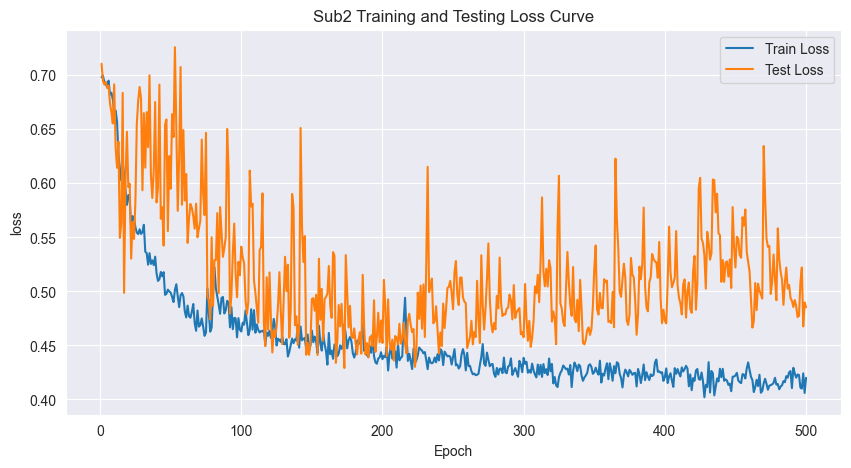

<Figure size 640x480 with 0 Axes>

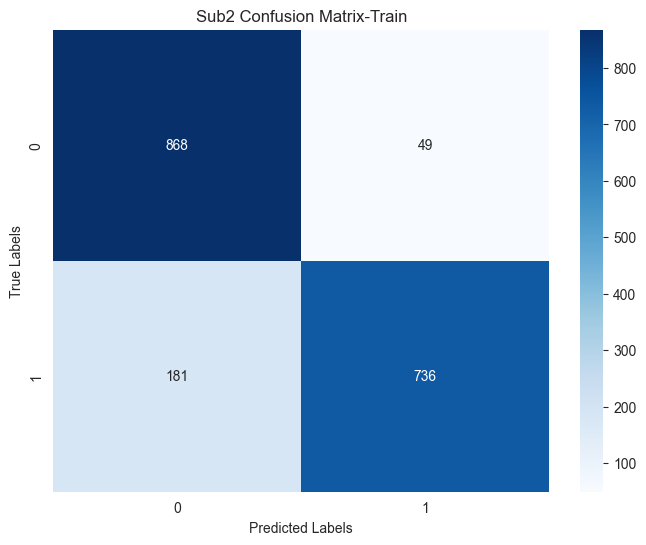

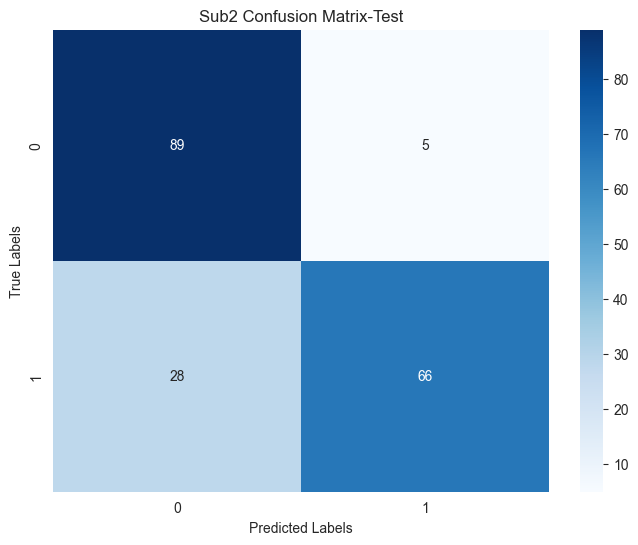

第 1 折（测试序号 0）Acc: 82.45%

========== 开始第 2/11 折LOOCV（测试序号：1）==========
Fold [2/11], Epoch [1/500], Step [1/8], Loss: 0.7010
Fold [2/11], Epoch [101/500], Step [1/8], Loss: 0.4650
Fold [2/11], Epoch [201/500], Step [1/8], Loss: 0.4424
Fold [2/11], Epoch [301/500], Step [1/8], Loss: 0.4074
Fold [2/11], Epoch [401/500], Step [1/8], Loss: 0.3866


<Figure size 640x480 with 0 Axes>

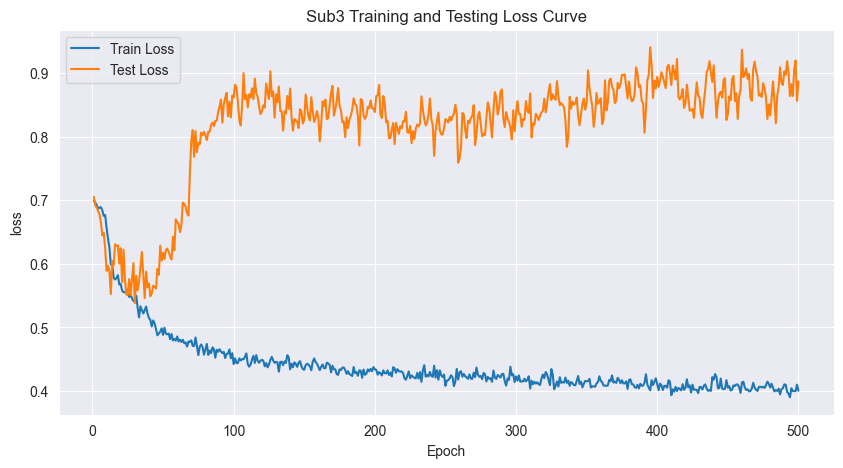

<Figure size 640x480 with 0 Axes>

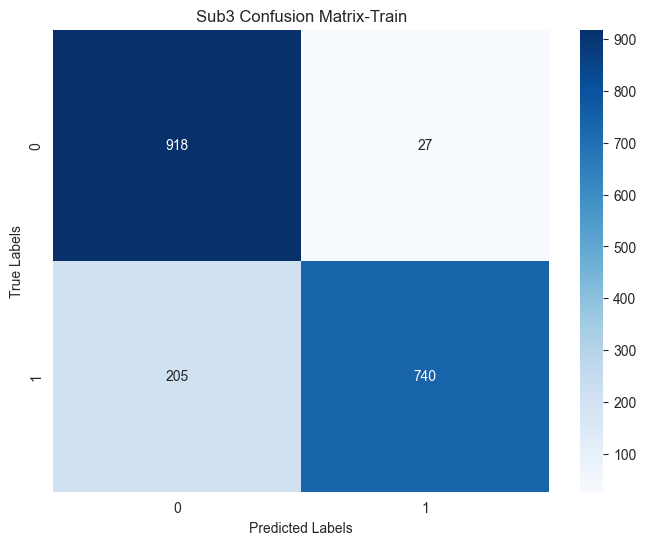

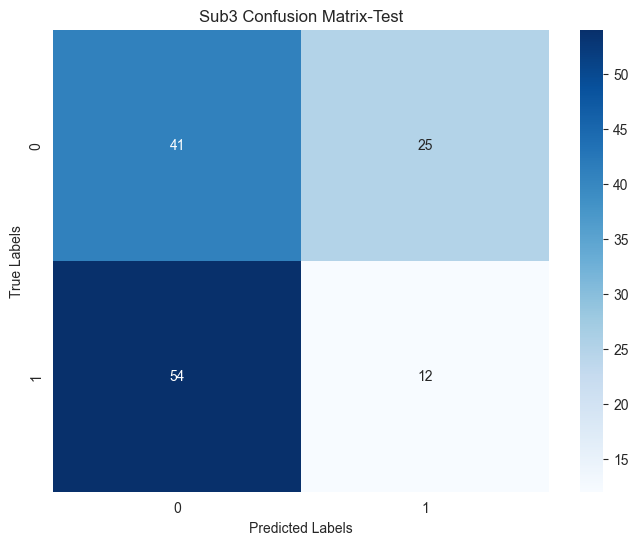

第 2 折（测试序号 1）Acc: 40.15%

========== 开始第 3/11 折LOOCV（测试序号：2）==========
Fold [3/11], Epoch [1/500], Step [1/8], Loss: 0.6871
Fold [3/11], Epoch [101/500], Step [1/8], Loss: 0.4494
Fold [3/11], Epoch [201/500], Step [1/8], Loss: 0.4276
Fold [3/11], Epoch [301/500], Step [1/8], Loss: 0.4077
Fold [3/11], Epoch [401/500], Step [1/8], Loss: 0.4071


<Figure size 640x480 with 0 Axes>

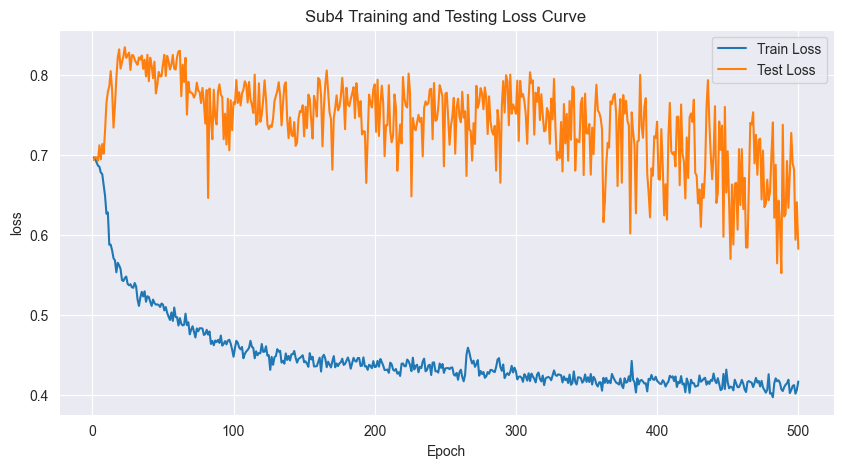

<Figure size 640x480 with 0 Axes>

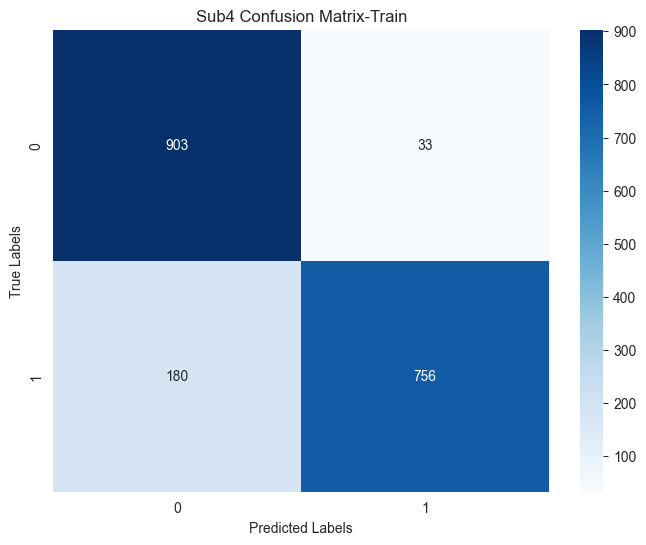

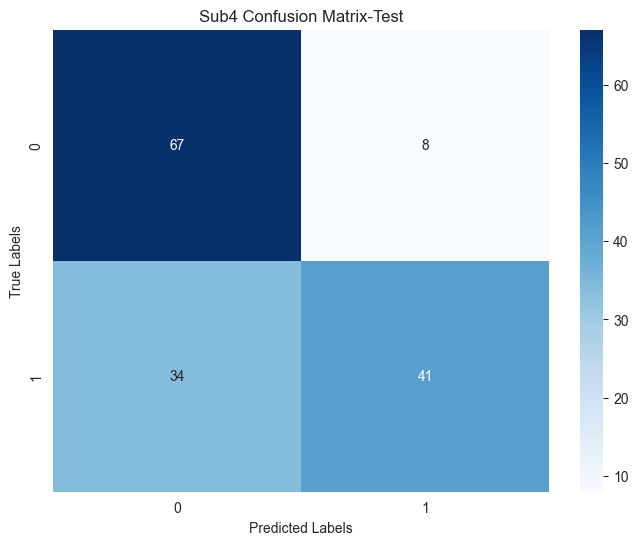

第 3 折（测试序号 2）Acc: 72.00%

========== 开始第 4/11 折LOOCV（测试序号：3）==========
Fold [4/11], Epoch [1/500], Step [1/8], Loss: 0.7012
Fold [4/11], Epoch [101/500], Step [1/8], Loss: 0.4668
Fold [4/11], Epoch [201/500], Step [1/8], Loss: 0.4493
Fold [4/11], Epoch [301/500], Step [1/8], Loss: 0.3811
Fold [4/11], Epoch [401/500], Step [1/8], Loss: 0.4103


<Figure size 640x480 with 0 Axes>

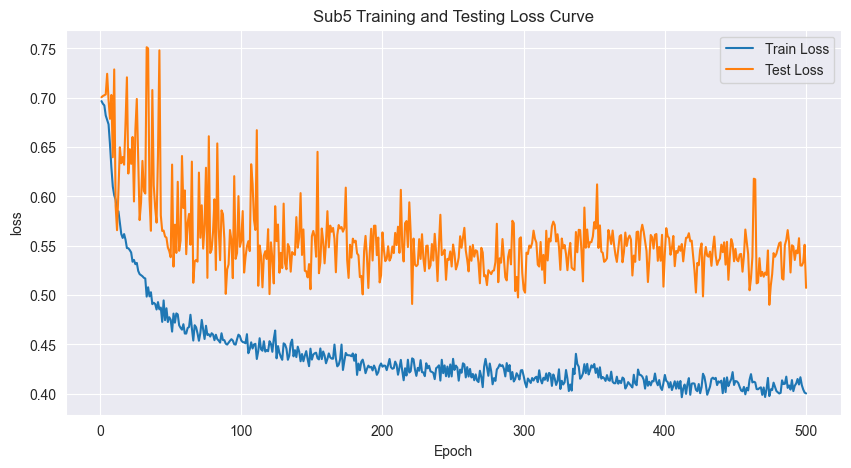

<Figure size 640x480 with 0 Axes>

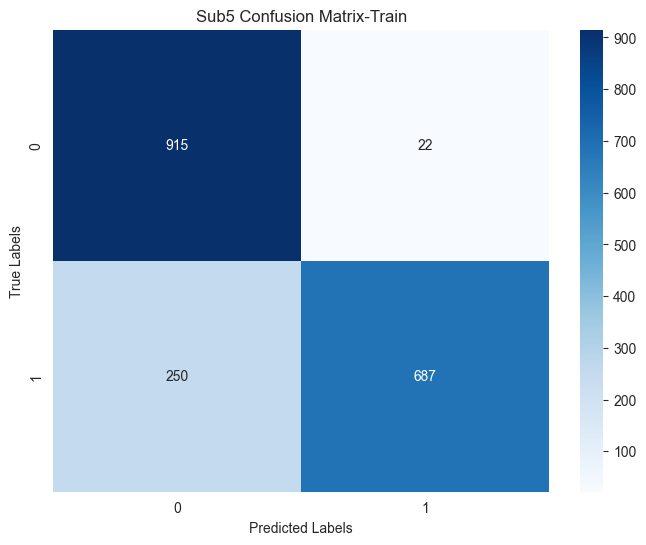

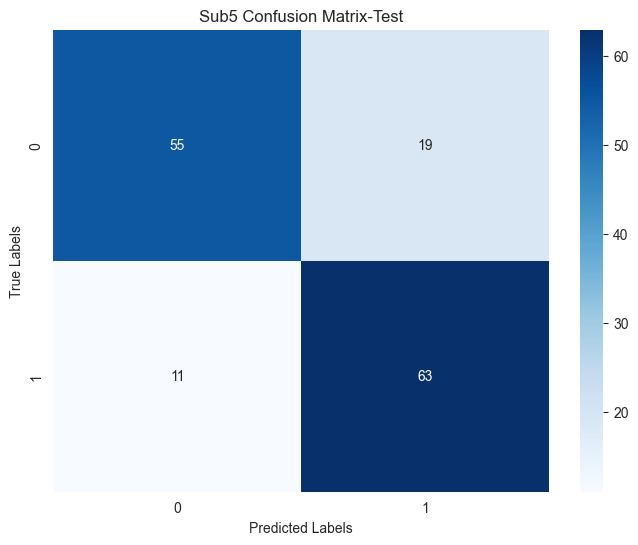

第 4 折（测试序号 3）Acc: 79.73%

========== 开始第 5/11 折LOOCV（测试序号：4）==========
Fold [5/11], Epoch [1/500], Step [1/8], Loss: 0.6923
Fold [5/11], Epoch [101/500], Step [1/8], Loss: 0.5043
Fold [5/11], Epoch [201/500], Step [1/8], Loss: 0.4817
Fold [5/11], Epoch [301/500], Step [1/8], Loss: 0.4745
Fold [5/11], Epoch [401/500], Step [1/8], Loss: 0.4381


<Figure size 640x480 with 0 Axes>

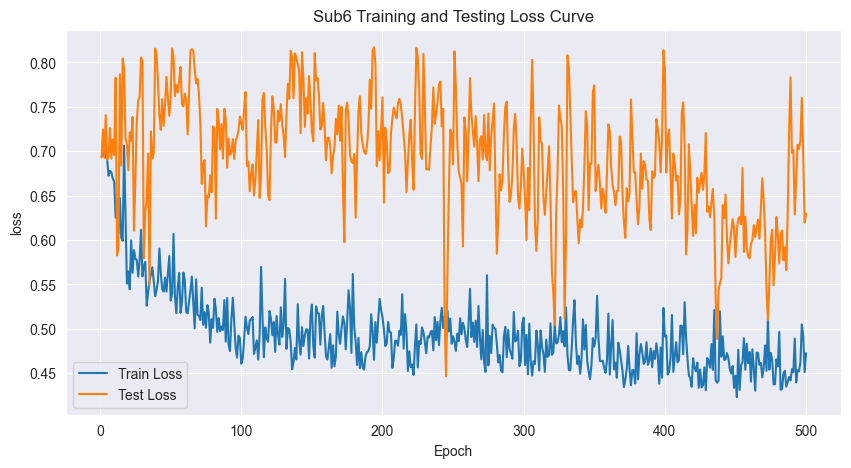

<Figure size 640x480 with 0 Axes>

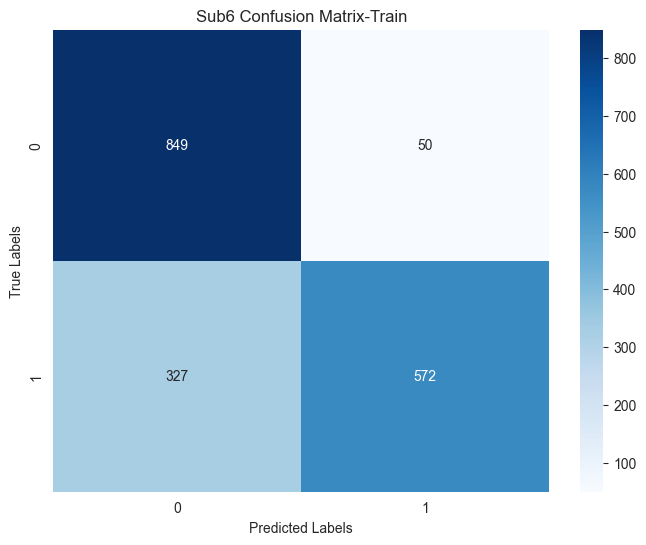

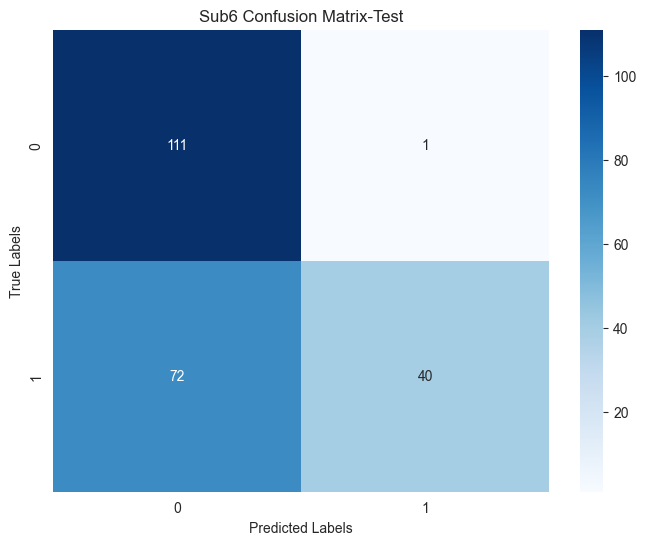

第 5 折（测试序号 4）Acc: 67.41%

========== 开始第 6/11 折LOOCV（测试序号：5）==========
Fold [6/11], Epoch [1/500], Step [1/8], Loss: 0.7337
Fold [6/11], Epoch [101/500], Step [1/8], Loss: 0.5127
Fold [6/11], Epoch [201/500], Step [1/8], Loss: 0.4409
Fold [6/11], Epoch [301/500], Step [1/8], Loss: 0.4465
Fold [6/11], Epoch [401/500], Step [1/8], Loss: 0.4308


<Figure size 640x480 with 0 Axes>

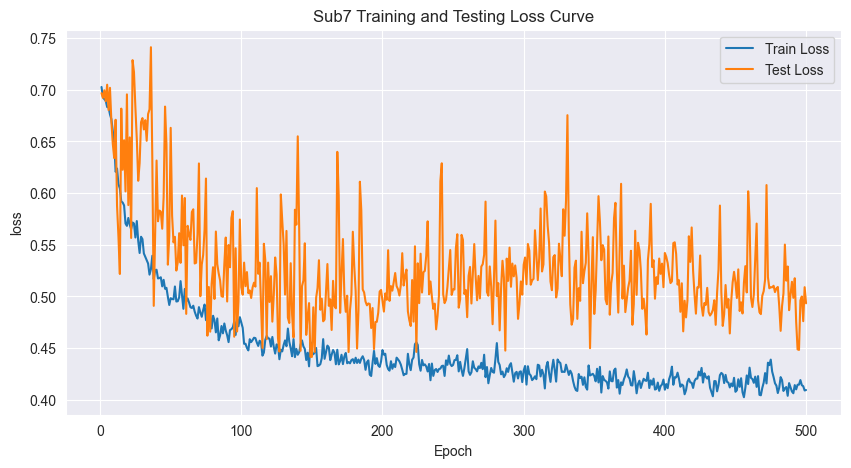

<Figure size 640x480 with 0 Axes>

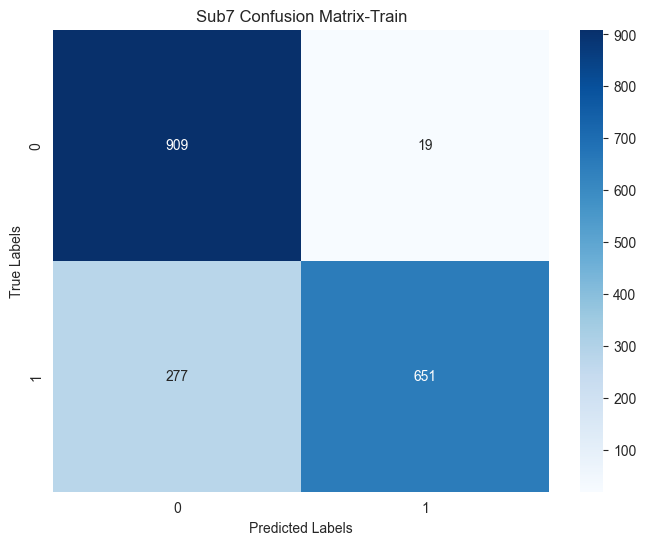

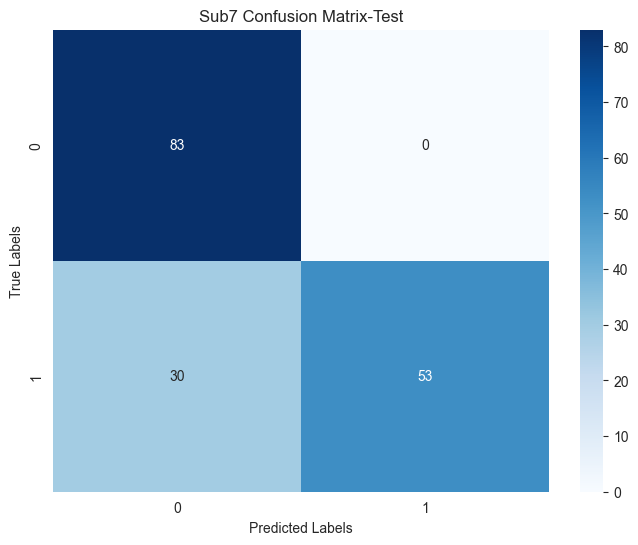

第 6 折（测试序号 5）Acc: 81.93%

========== 开始第 7/11 折LOOCV（测试序号：6）==========
Fold [7/11], Epoch [1/500], Step [1/8], Loss: 0.7348
Fold [7/11], Epoch [101/500], Step [1/8], Loss: 0.4497
Fold [7/11], Epoch [201/500], Step [1/8], Loss: 0.4218
Fold [7/11], Epoch [301/500], Step [1/8], Loss: 0.3778
Fold [7/11], Epoch [401/500], Step [1/8], Loss: 0.4297


<Figure size 640x480 with 0 Axes>

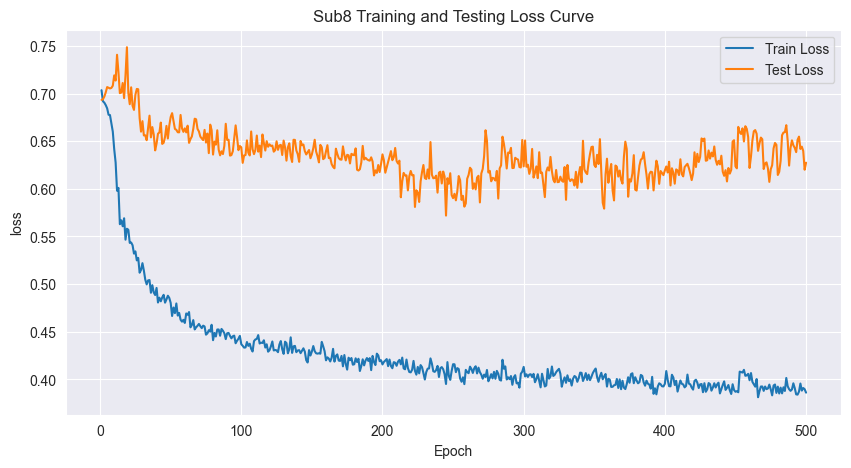

<Figure size 640x480 with 0 Axes>

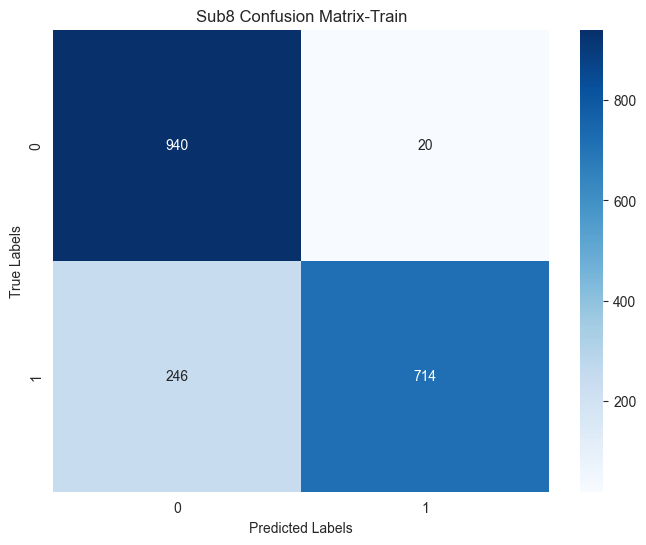

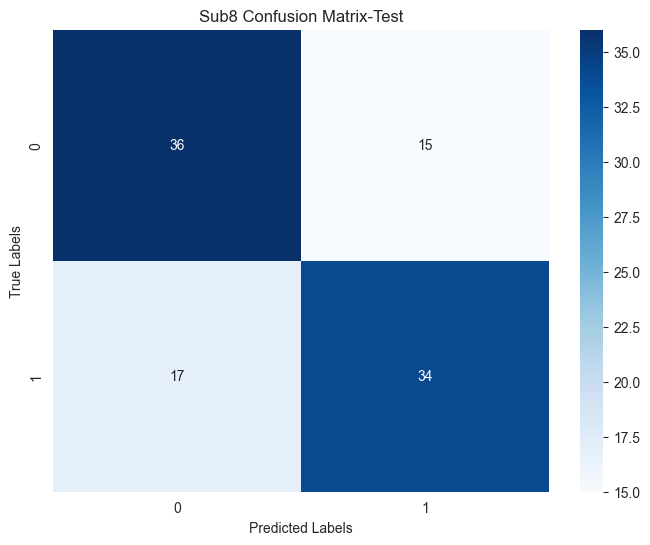

第 7 折（测试序号 6）Acc: 68.63%

========== 开始第 8/11 折LOOCV（测试序号：7）==========
Fold [8/11], Epoch [1/500], Step [1/7], Loss: 0.6918
Fold [8/11], Epoch [101/500], Step [1/7], Loss: 0.4625
Fold [8/11], Epoch [201/500], Step [1/7], Loss: 0.4270
Fold [8/11], Epoch [301/500], Step [1/7], Loss: 0.4239
Fold [8/11], Epoch [401/500], Step [1/7], Loss: 0.4194


<Figure size 640x480 with 0 Axes>

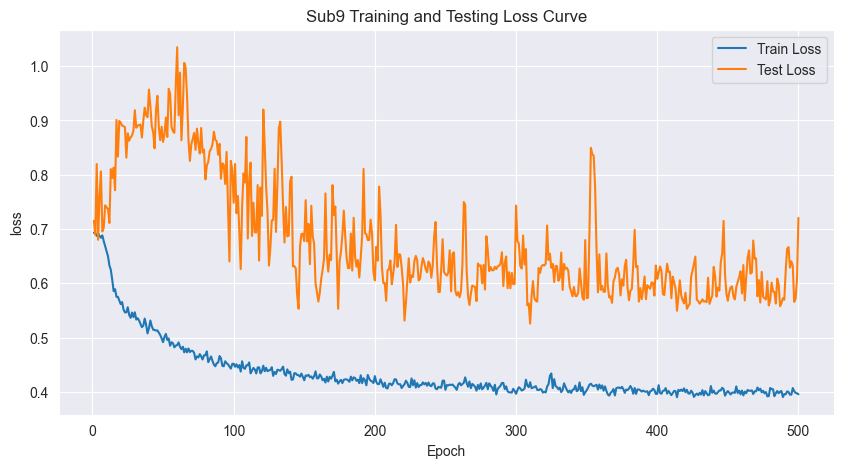

<Figure size 640x480 with 0 Axes>

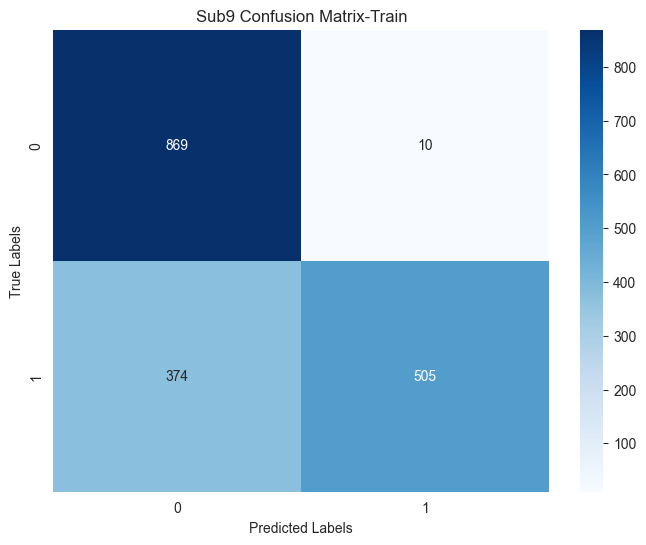

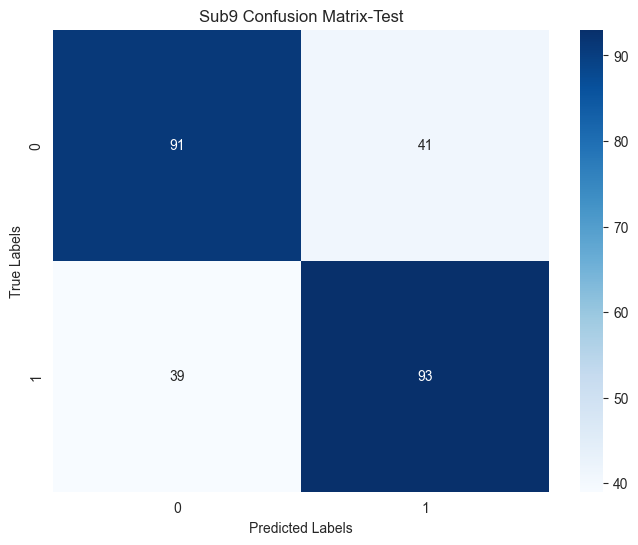

第 8 折（测试序号 7）Acc: 69.70%

========== 开始第 9/11 折LOOCV（测试序号：8）==========
Fold [9/11], Epoch [1/500], Step [1/7], Loss: 0.6998
Fold [9/11], Epoch [101/500], Step [1/7], Loss: 0.4621
Fold [9/11], Epoch [201/500], Step [1/7], Loss: 0.4275
Fold [9/11], Epoch [301/500], Step [1/7], Loss: 0.4136
Fold [9/11], Epoch [401/500], Step [1/7], Loss: 0.4169


<Figure size 640x480 with 0 Axes>

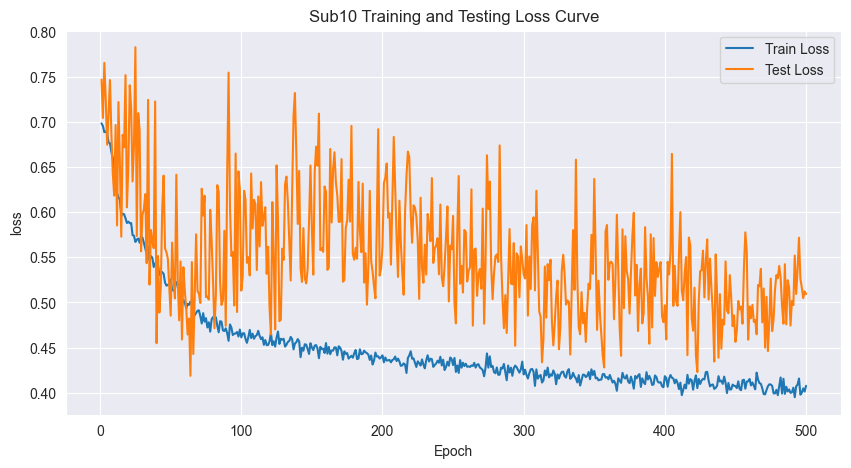

<Figure size 640x480 with 0 Axes>

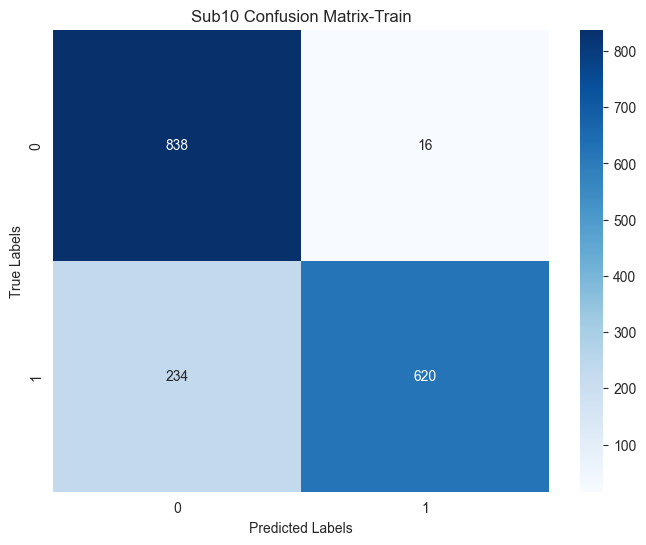

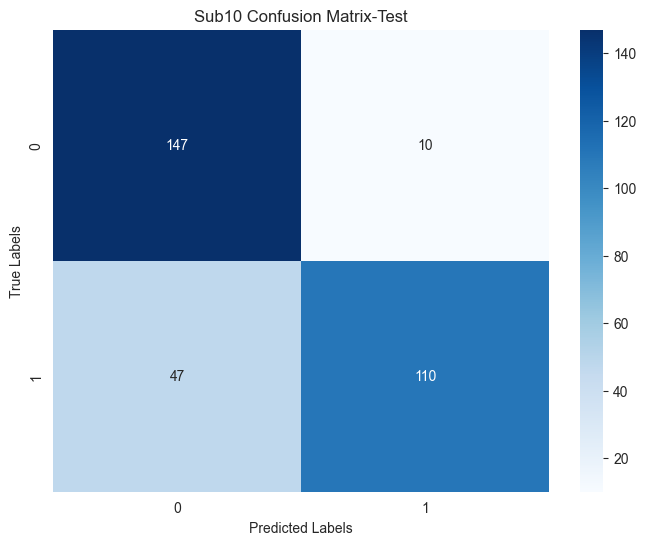

第 9 折（测试序号 8）Acc: 81.85%

========== 开始第 10/11 折LOOCV（测试序号：9）==========
Fold [10/11], Epoch [1/500], Step [1/8], Loss: 0.6970
Fold [10/11], Epoch [101/500], Step [1/8], Loss: 0.4198
Fold [10/11], Epoch [201/500], Step [1/8], Loss: 0.4138
Fold [10/11], Epoch [301/500], Step [1/8], Loss: 0.3999
Fold [10/11], Epoch [401/500], Step [1/8], Loss: 0.4090


<Figure size 640x480 with 0 Axes>

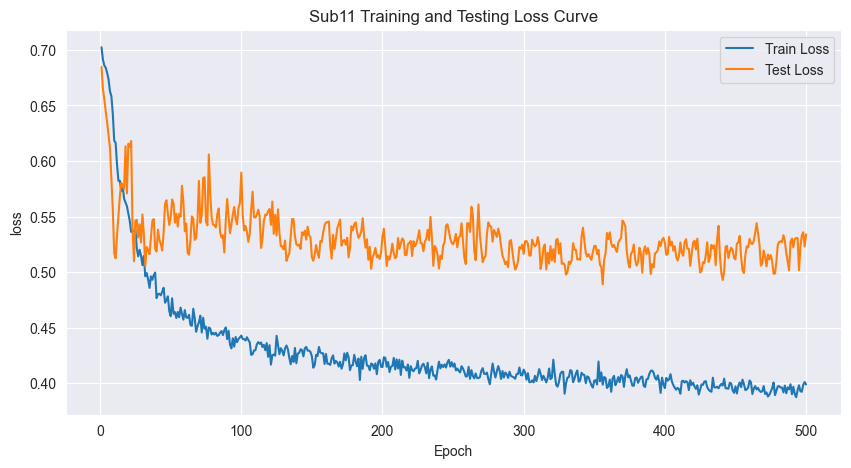

<Figure size 640x480 with 0 Axes>

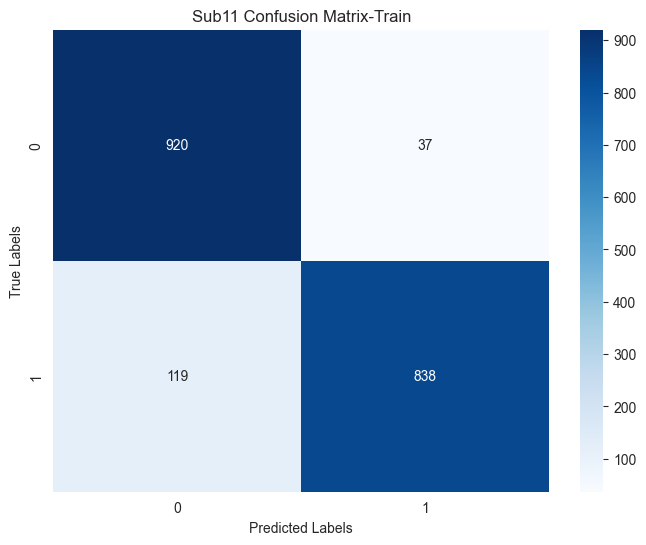

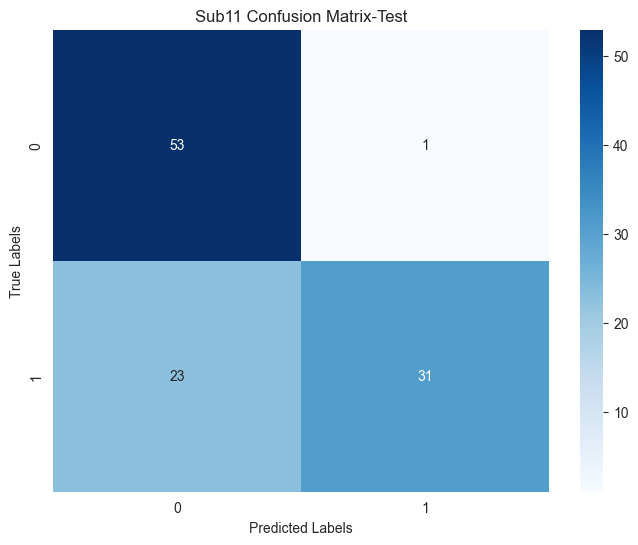

第 10 折（测试序号 9）Acc: 77.78%

========== 开始第 11/11 折LOOCV（测试序号：10）==========
Fold [11/11], Epoch [1/500], Step [1/8], Loss: 0.7008
Fold [11/11], Epoch [101/500], Step [1/8], Loss: 0.8289
Fold [11/11], Epoch [201/500], Step [1/8], Loss: 0.8248
Fold [11/11], Epoch [301/500], Step [1/8], Loss: 0.7937
Fold [11/11], Epoch [401/500], Step [1/8], Loss: 0.8367


<Figure size 640x480 with 0 Axes>

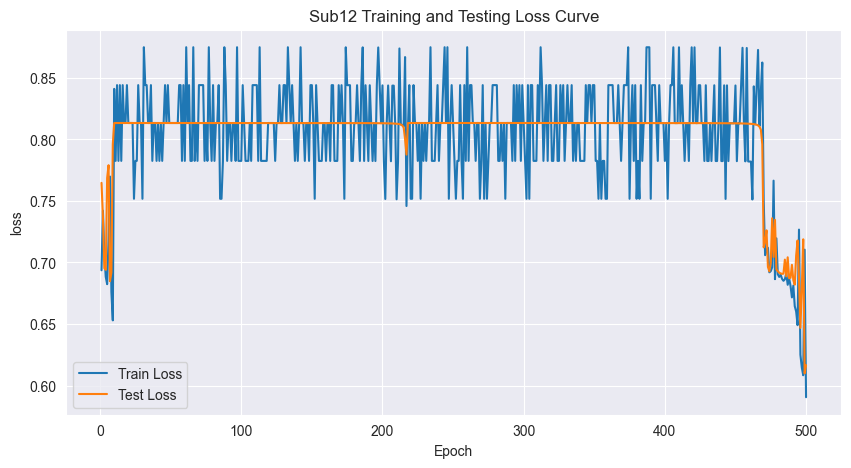

<Figure size 640x480 with 0 Axes>

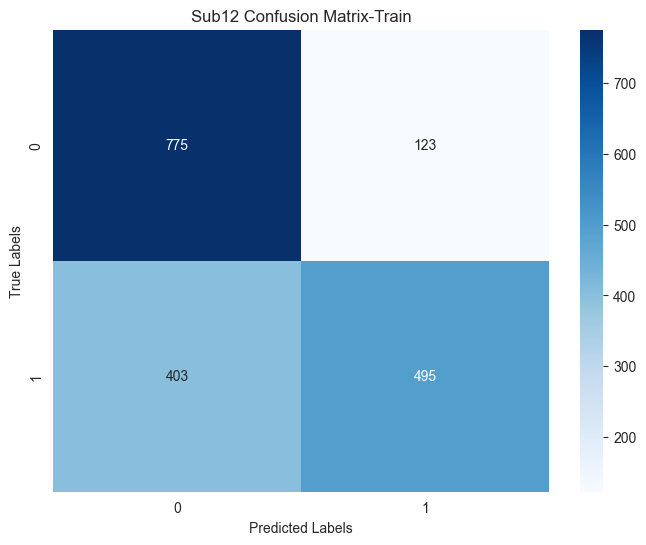

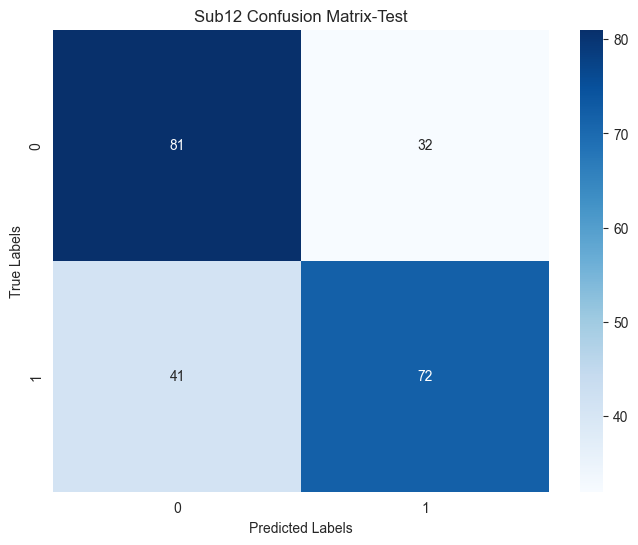

第 11 折（测试序号 10）Acc: 67.70%

========== LOOCV最终结果 ==========
11折平均测试准确率: 71.76% (标准差: 11.55%)


<Figure size 640x480 with 0 Axes>

In [10]:
datas = []
test_datas = []

# 定义超参数（保持不变）
lr = 0.01
wd = 0.001
bs = 256
op = 'SGD'
dr = 0.5
epoches = 500
all_loocv_accuracies = []
all_loocv_train_losses = []
all_loocv_test_losses = []

# 原始数据处理（保持不变）
predata = torch.Tensor(EEGsample)
label = torch.Tensor(substate).long()
index = torch.Tensor(subindex).long() - 1
inpt = predata.reshape(-1, 1, 30, 384)   # (2022, 1, 30, 384)

# 提取所有唯一的样本序号（0-10），共11个
unique_index = torch.unique(index).numpy()
n_folds = len(unique_index)

# ====================== 核心：LOOCV循环 ======================
for fold_idx, test_idx in enumerate(unique_index):
    print(f"\n========== 开始第 {fold_idx+1}/{n_folds} 折LOOCV（测试序号：{test_idx}）==========")

    # 1. 划分本次LOOCV的训练/测试序号
    train_index_ids = [idx for idx in unique_index if idx != test_idx]
    test_index_ids = [test_idx]

    # 2. 生成训练/测试掩码
    train_mask = torch.zeros_like(index, dtype=torch.bool)
    for idx in train_index_ids:
        train_mask = train_mask | (index == idx)

    test_mask = torch.zeros_like(index, dtype=torch.bool)
    test_mask = test_mask | (index == test_idx)

    # 3. 拆分训练/测试数据
    train_inpt = inpt[train_mask]
    train_label = label[train_mask]
    test_inpt = inpt[test_mask]
    test_label = label[test_mask]

    # 4. 构建数据集和DataLoader
    train_dataset = TensorDataset(train_inpt, train_label)
    test_dataset = TensorDataset(test_inpt, test_label)
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)

    # 5. 重新初始化模型/优化器（关键！每次LOOCV必须重新初始化）
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ==================== 修改点：使用 EEGViT ====================
    net = EEGViT(
        n_classes=2,
        channels=30,
        samples=384,
        drop_out=dr,
        kernelLength=32,
        kernelLength2=16,
        F1=16,
        D=2,
        F2=32,
        # ViT 参数可根据需要微调
        vit_dim=256,
        vit_depth=6,
        vit_heads=8,
        vit_mlp_dim=512,
        vit_dropout=0.1
    ).to(device)

    criterion = nn.CrossEntropyLoss().to(device)

    if op == 'Adam':
        optimizer = optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoches, eta_min=0)
    else:
        optimizer = optim.SGD(net.parameters(), lr=lr, weight_decay=wd,
                              momentum=0.9, nesterov=True)

    # 初始化本次折的损失记录
    train_losses = []
    test_losses = []

    # 6. 训练模型
    for epoch in range(epoches):
        net.train()
        train_loss = 0.0

        for i, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            if op == 'Adam':
                scheduler.step()

            if epoch % 100 == 0 and i % 10 == 0:
                print(f'Fold [{fold_idx+1}/{n_folds}], Epoch [{epoch+1}/{epoches}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

            train_loss += loss.item()

        # 验证阶段
        net.eval()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # 调用您已有的 get_losses 函数
        test_losses = get_losses(test_losses, test_loader, net, device)

    # 7. 评估本次折的模型
    net.eval()
    all_train_targets, all_train_predictions = get_predictions(train_loader, net, device)
    all_test_targets, all_test_predictions = get_predictions(test_loader, net, device)

    # 保存结果
    sub_path = os.path.join(path, 'EEGVit', f'fold_{fold_idx+1}_testidx_{test_idx}')  # 改为 EEGVit 文件夹
    os.makedirs(sub_path, exist_ok=True)

    loss_curve(epoches, train_losses, test_losses, folder_path=sub_path, sub=fold_idx+1)
    plt.clf()
    plot_confusion_matrix(all_train_targets, all_train_predictions,
                         all_test_targets, all_test_predictions,
                         folder_path=sub_path, sub=fold_idx+1)
    plt.clf()

    # 计算准确率
    test_accuracy = calculate_accuracy(test_loader, net, device)
    all_loocv_accuracies.append(test_accuracy)
    print(f'第 {fold_idx+1} 折（测试序号 {test_idx}）Acc: {test_accuracy:.2f}%')

    all_loocv_train_losses.append(train_losses)
    all_loocv_test_losses.append(test_losses)

    # 写入报告
    with open(report_path, 'a') as f:
        f.write(f'LOOCV Fold {fold_idx+1}（测试序号 {test_idx}）Acc: {test_accuracy:.2f}%\n')

# ====================== LOOCV结束：计算最终结果 ======================
mean_loocv_accuracy = np.mean(all_loocv_accuracies)
std_loocv_accuracy = np.std(all_loocv_accuracies)

print(f"\n========== LOOCV最终结果 ==========")
print(f'11折平均测试准确率: {mean_loocv_accuracy:.2f}% (标准差: {std_loocv_accuracy:.2f}%)')

with open(report_path, 'a') as f:
    f.write(f'\nLOOCV 11折平均准确率: {mean_loocv_accuracy:.2f}% (标准差: {std_loocv_accuracy:.2f}%)\n')
    f.write(f'各折准确率: {[f"{acc:.2f}%" for acc in all_loocv_accuracies]}\n')